# Social Anxiety Prediction

Notebook này xây dựng mô hình Machine Learning để dự đoán mức độ lo âu xã hội dựa trên các thông tin về lối sống, sức khỏe, phản ứng sinh lý và yếu tố cá nhân.

## Mục tiêu
- Phân tích dữ liệu ban đầu.
- Thực hiện preprocessing dữ liệu.
- Xây dựng thêm các đặc trưng mới bằng Feature Engineering.
- So sánh nhiều mô hình Machine Learning.
- Tìm mô hình và bộ tham số tốt nhất.
- Đánh giá mô hình cuối cùng trên tập test.
- Lưu mô hình để sử dụng cho demo hoặc triển khai.

## Loại bài toán
Target là `Anxiety Level`, có giá trị từ 1 đến 10.  
Trong notebook này, bài toán được xử lý theo hướng **Regression**, vì target thể hiện mức độ lo âu theo thang điểm có thứ tự.

# Import thư viện

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

import joblib

# Load Dataset

Ở bước này, ta đọc dữ liệu từ file CSV và xem nhanh một vài dòng đầu tiên để hiểu cấu trúc dữ liệu.

In [4]:
DATA_PATH = "enhanced_anxiety_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (11000, 19)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


# Data Overview

Ta kiểm tra:
- Số dòng, số cột.
- Kiểu dữ liệu của từng cột.
- Missing values.
- Duplicate rows.
- Thống kê mô tả của các biến số.

Bước này giúp đánh giá chất lượng dữ liệu trước khi preprocessing.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

In [6]:
df.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10)
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.241727,6.650691,2.942136,286.090000,9.701636,5.856364,90.916000,20.957545,3.080636,2.427818,5.181818,3.929364
std,13.236140,1.227509,1.827825,144.813157,5.689713,2.927202,17.325721,5.160107,1.398877,2.183106,2.895243,2.122533
min,18.000000,2.300000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000
25%,29.000000,5.900000,1.500000,172.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000
50%,40.000000,6.700000,2.800000,273.000000,10.000000,6.000000,92.000000,21.000000,3.000000,2.000000,5.000000,4.000000
75%,51.000000,7.500000,4.200000,382.000000,15.000000,8.000000,106.000000,25.000000,4.000000,4.000000,8.000000,5.000000
max,64.000000,11.300000,10.100000,599.000000,19.000000,10.000000,119.000000,29.000000,5.000000,12.000000,10.000000,10.000000


In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


# Exploratory Data Analysis

Phần EDA giúp quan sát phân phối dữ liệu, mối quan hệ giữa các biến và target.  
Notebook chỉ chọn một số biểu đồ quan trọng để tránh bị rối.

In [9]:
target_col = "Anxiety Level (1-10)"

## 1. Phân phối biến mục tiêu (Anxiety Level)

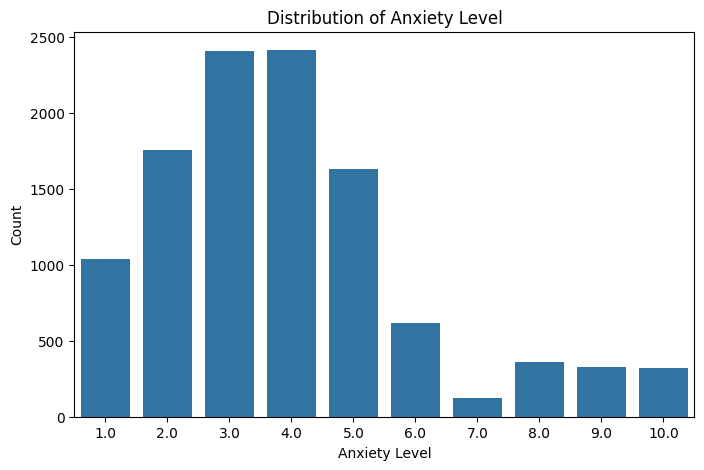

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df[target_col])
plt.title("Distribution of Anxiety Level")
plt.xlabel("Anxiety Level")
plt.ylabel("Count")
plt.show()

Biểu đồ phân phối cho thấy biến mục tiêu `Anxiety Level` không phân bố đồng đều giữa các mức độ lo âu.

Dữ liệu tập trung chủ yếu ở các mức trung bình, đặc biệt từ mức **3 đến 5**, trong khi các mức cao hơn như **7 đến 10** có số lượng mẫu thấp hơn đáng kể. Điều này cho thấy target có hiện tượng **mất cân bằng nhẹ đến trung bình**.

Vì target là biến rời rạc có giá trị từ 1 đến 10, để giữ phân phối dữ liệu ổn định giữa các tập huấn luyện và kiểm tra, phương pháp **stratified train-test split** sẽ được áp dụng dựa trên giá trị target. Ngoài ra, sample weighting cũng được xem xét để giảm ảnh hưởng của sự mất cân bằng này trong quá trình huấn luyện mô hình.

## 2. Mối tương quan giữa các biến số

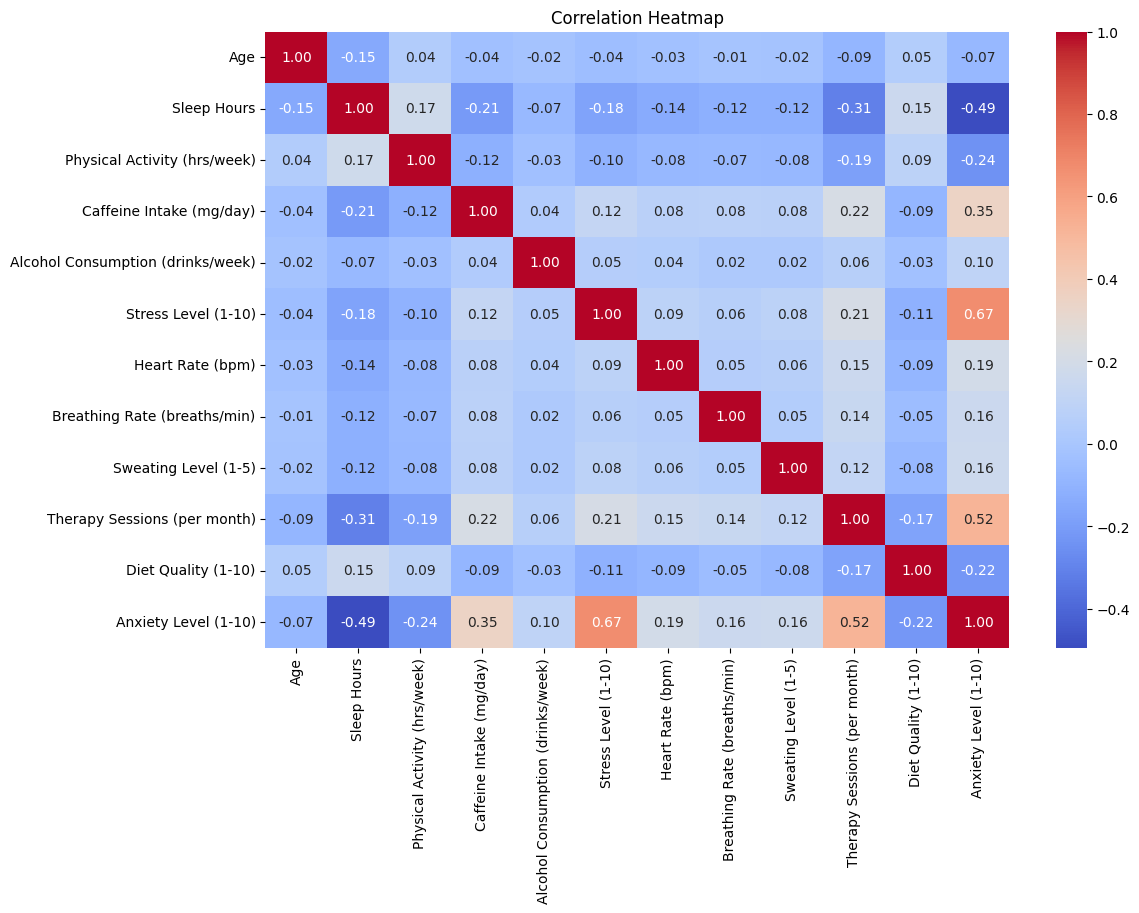

In [11]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Correlation heatmap cho thấy một số đặc trưng có mối liên hệ đáng chú ý với mức độ lo âu:

- `Stress Level` có tương quan dương mạnh nhất với `Anxiety Level` (**0.67**), cho thấy stress là một yếu tố quan trọng ảnh hưởng đến mức độ lo âu.
- `Therapy Sessions` cũng có tương quan dương tương đối mạnh (**0.52**), cho thấy những người có mức lo âu cao có xu hướng tham gia trị liệu nhiều hơn.
- `Sleep Hours` có tương quan âm khá rõ (**-0.49**), cho thấy ngủ ít thường đi kèm với mức độ lo âu cao hơn.
- `Caffeine Intake` có tương quan dương mức trung bình (**0.35**), gợi ý rằng việc tiêu thụ caffeine có thể liên quan đến trạng thái lo âu.
- `Diet Quality` có tương quan âm nhẹ (**-0.22**), cho thấy chế độ ăn tốt hơn có thể liên quan đến mức lo âu thấp hơn.

Ngoài ra, một số biến có mối liên hệ với nhau:

- `Sleep Hours` và `Therapy Sessions` có tương quan âm (**-0.31**)
- `Physical Activity` và `Anxiety Level` có tương quan âm (**-0.24**)

Những quan sát này gợi ý rằng việc kết hợp nhiều biến để tạo đặc trưng mới có thể giúp mô hình học tốt hơn thay vì chỉ sử dụng từng biến riêng lẻ.

## 3. Phân tích outlier

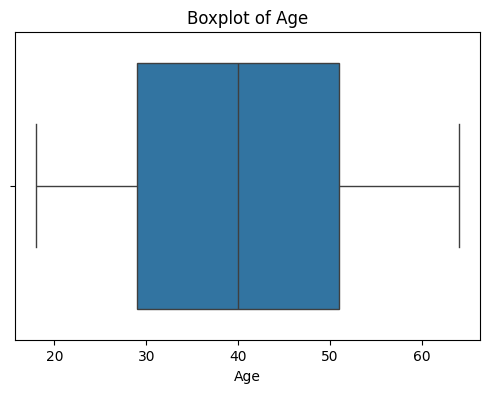

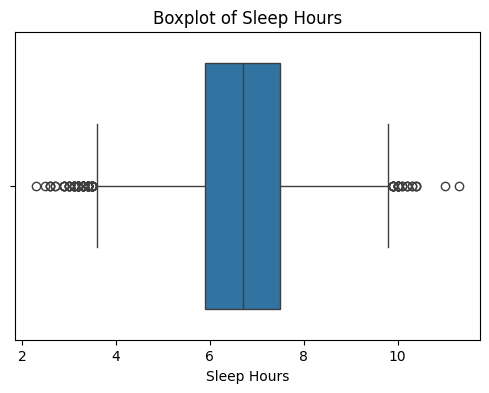

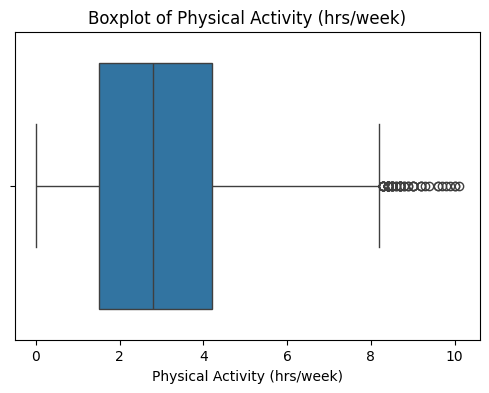

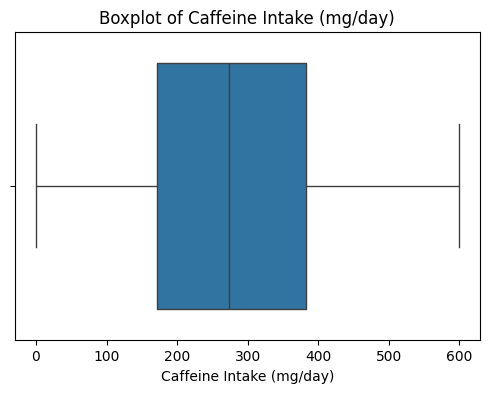

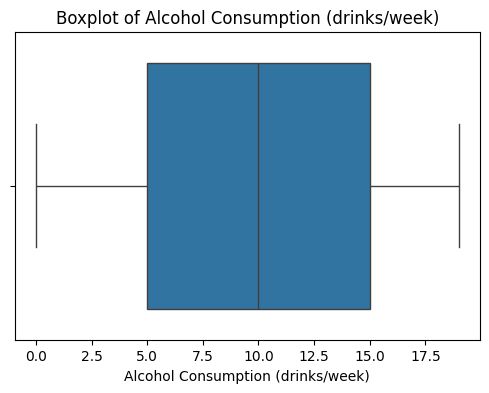

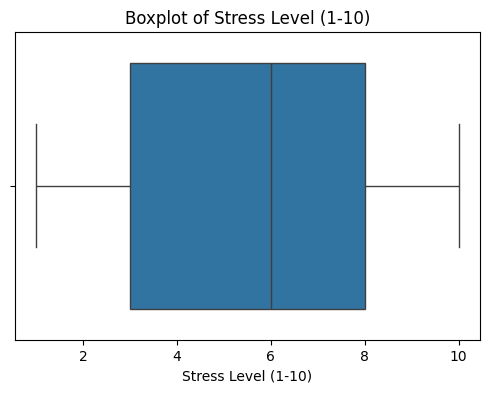

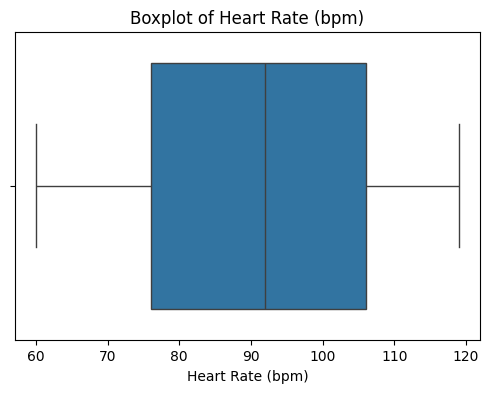

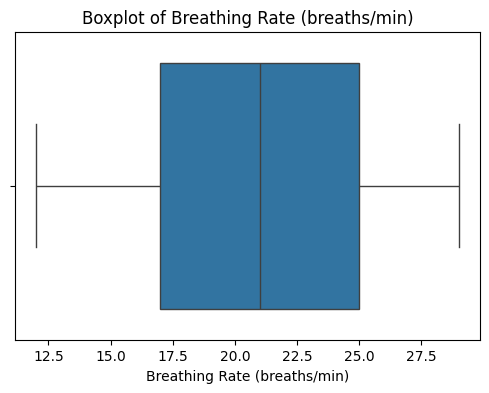

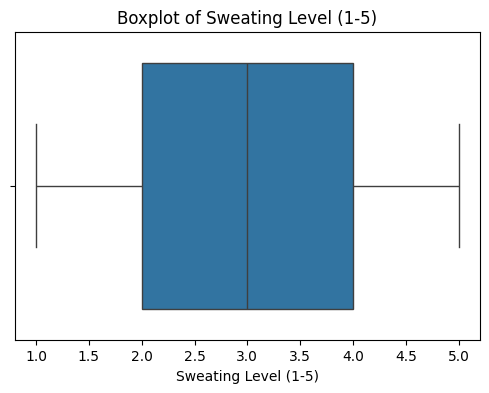

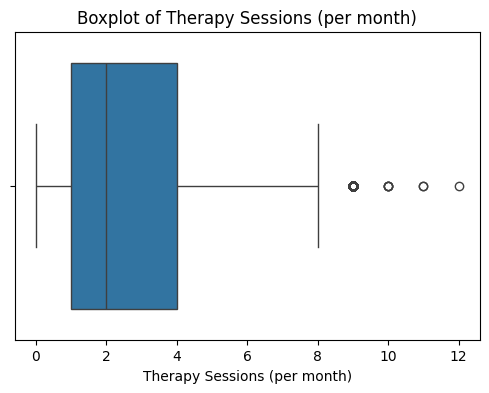

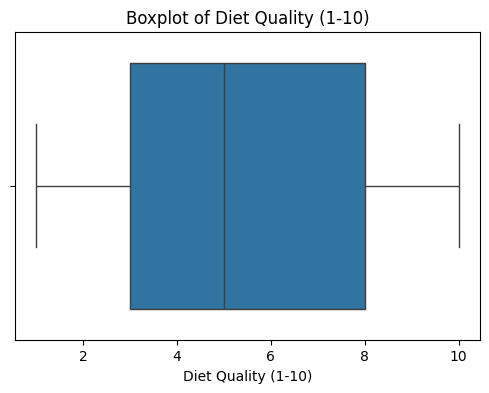

In [12]:
for col in numeric_cols:
    if col != target_col:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

Boxplot cho thấy một số biến số có xuất hiện outlier:

- `Sleep Hours` có một số giá trị rất thấp và rất cao so với phần lớn dữ liệu.
- `Physical Activity` xuất hiện nhiều giá trị cao bất thường.
- `Therapy Sessions` có một số cá thể tham gia trị liệu với tần suất cao hơn đáng kể.

Tuy nhiên, các giá trị này vẫn có ý nghĩa thực tế và phản ánh sự khác biệt giữa các cá nhân, đặc biệt trong bài toán liên quan đến sức khỏe tâm lý. Vì vậy, các outlier này sẽ **không bị loại bỏ**, tránh làm mất thông tin quan trọng.

Thay vào đó, để giảm ảnh hưởng của outlier lên mô hình, phương pháp **RobustScaler** sẽ được ưu tiên trong bước preprocessing.

## 4. Phân tích biến phân loại


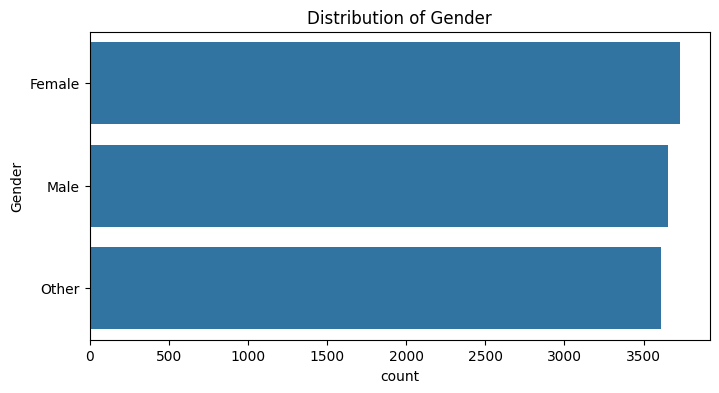

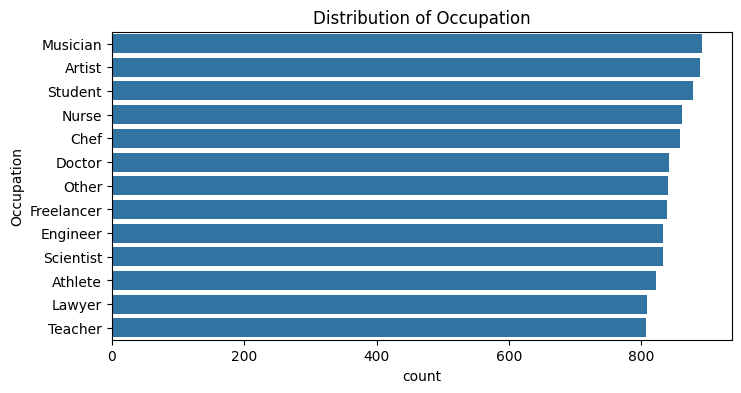

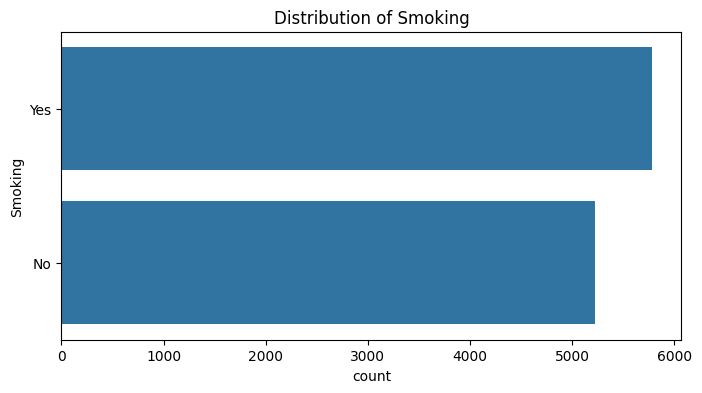

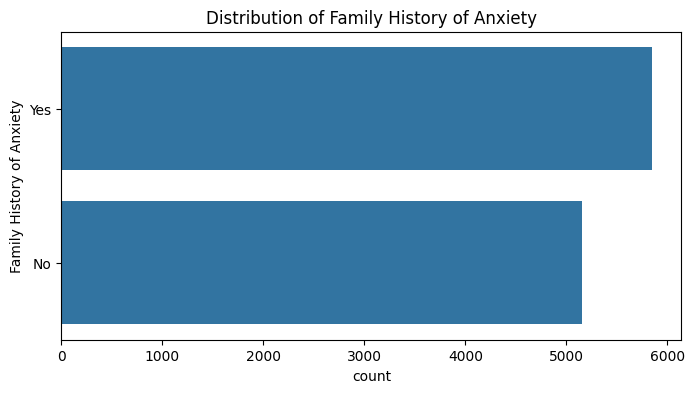

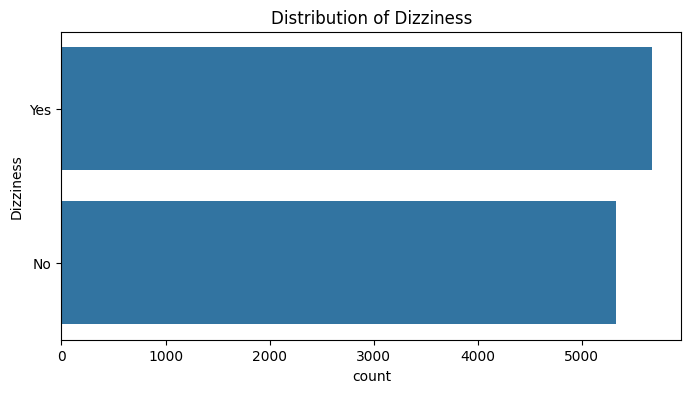

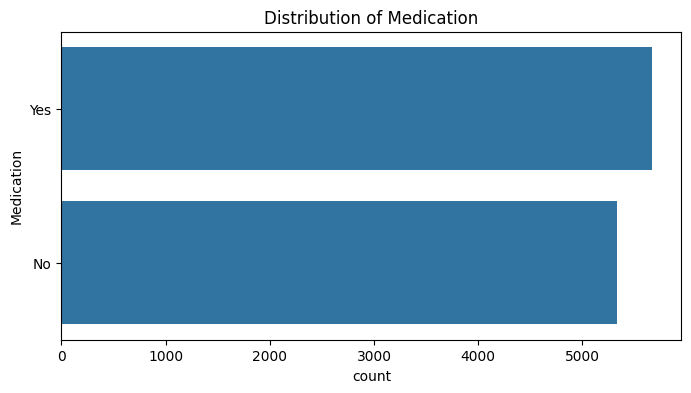

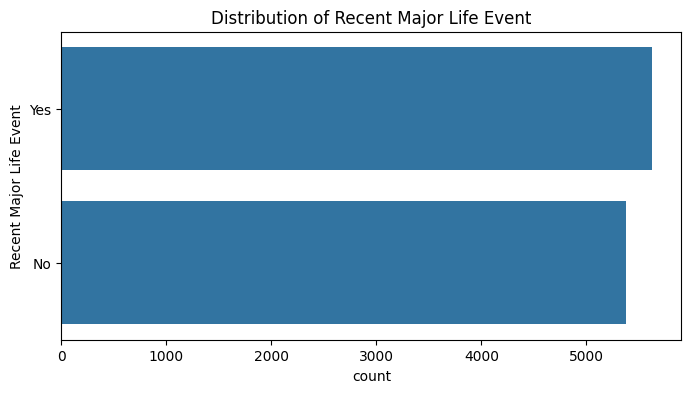

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

Các biến categorical được kiểm tra bằng countplot cho thấy có sự khác biệt về số lượng giữa các nhóm, tuy nhiên không xuất hiện mất cân bằng nghiêm trọng.

Do các biến này không mang tính thứ tự tự nhiên, phương pháp **One-Hot Encoding** sẽ được sử dụng thay vì Label Encoding để tránh tạo ra quan hệ thứ tự giả giữa các nhóm.

# Data Preprocessing

## 1. Binary Encoding

Các biến có giá trị Yes/No sẽ được chuyển sang dạng số (1/0) để mô hình có thể xử lý.


In [14]:
def clean_binary_columns(data):

    data = data.copy()

    binary_map = {
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0,
        "Y": 1,
        "N": 0,
        True: 1,
        False: 0
    }

    for col in data.columns:
        unique_values = set(data[col].dropna().unique())

        if unique_values.issubset(set(binary_map.keys())):
            data[col] = data[col].map(binary_map)

    return data

In [15]:
df_clean = clean_binary_columns(df)

df_clean.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8,3.0
2,64,Male,Other,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1,2.0
4,49,Female,Other,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3,1.0


Các biến categorical như `Gender` và `Occupation` sẽ được mã hóa bằng One-Hot Encoding để tránh tạo ra quan hệ thứ tự giả giữa các nhóm.


## 2. Build Preprocessing Pipeline

Pipeline preprocessing gồm:

- RobustScaler cho numeric features
- OneHotEncoder cho categorical features

In [16]:
def get_feature_types(data, target_col):
    """
    Separate numeric and categorical features.
    """

    X = data.drop(columns=[target_col])

    numeric_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object"]
    ).columns.tolist()

    return numeric_features, categorical_features

In [17]:
def build_preprocessor(data, target_col):
    """
    Build preprocessing pipeline.
    """

    numeric_features, categorical_features = get_feature_types(
        data,
        target_col
    )

    numeric_transformer = Pipeline(
        steps=[
            ("scaler", RobustScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer,
                numeric_features
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features
            )
        ],
        remainder="drop"
    )

    return preprocessor

In [18]:
preprocessor = build_preprocessor(
    df_clean,
    target_col
)

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


# Feature Engineering


Các đặc trưng mới được xây dựng dựa trên các quan sát từ EDA và giả thuyết rằng mức độ lo âu không chỉ phụ thuộc vào từng biến riêng lẻ, mà còn phụ thuộc vào sự kết hợp giữa nhiều yếu tố.

---

**1. Healthy_Lifestyle**

**Formula:**

$$
Healthy\_Lifestyle =
Sleep\ Hours
+
Physical\ Activity
+
Diet\ Quality
$$

**Ý nghĩa:**

Đặc trưng này đại diện cho mức độ duy trì lối sống lành mạnh của một cá nhân.

Bao gồm:

- thời gian ngủ
- mức độ vận động
- chất lượng chế độ ăn

Ngủ đủ, vận động thường xuyên và chế độ ăn tốt thường có tác động tích cực đến sức khỏe tinh thần.

Giá trị càng cao → lifestyle càng tích cực.

---

**2. Unhealthy_Lifestyle**

**Formula:**

$$
Unhealthy\_Lifestyle =
Caffeine\ Intake
+
Alcohol\ Consumption
+
Smoking
$$

**Ý nghĩa:**

Đặc trưng này tổng hợp các yếu tố lifestyle có thể ảnh hưởng tiêu cực đến trạng thái tinh thần.

Bao gồm:

- caffeine
- alcohol
- smoking

Các yếu tố này có thể làm tăng stress, rối loạn giấc ngủ hoặc làm nặng thêm anxiety.

Giá trị càng cao → lifestyle càng tiêu cực.

---

**3. Lifestyle_Balance**

**Formula:**

$$
Lifestyle\_Balance =
Healthy\_Lifestyle
-
Unhealthy\_Lifestyle
$$

**Ý nghĩa:**

Đặc trưng này thể hiện mức cân bằng tổng thể giữa các thói quen tốt và xấu.

Ví dụ:

- người ngủ đủ, tập luyện tốt nhưng uống nhiều caffeine
- người ít vận động nhưng không hút thuốc

Đặc trưng này giúp mô hình đánh giá trạng thái lifestyle tổng hợp.

Giá trị cao → cân bằng lifestyle tốt hơn.

---

**4. Stress_Sleep_Ratio**

**Formula:**

$$
Stress\_Sleep\_Ratio =
\frac{Stress\ Level}{Sleep\ Hours + 1}
$$

**Ý nghĩa:**

EDA cho thấy:

- Stress Level tương quan dương mạnh với Anxiety
- Sleep Hours tương quan âm

Do đó, stress có thể tác động khác nhau tùy thời lượng ngủ.

Ví dụ:

- stress cao + ngủ ít → nguy cơ anxiety cao
- stress cao + ngủ đủ → tác động nhẹ hơn

Số $+1$ được thêm để tránh chia cho 0.

---

**5. Therapy_Sleep_Ratio**

**Formula:**

$$
Therapy\_Sleep\_Ratio =
\frac{Therapy\ Sessions}{Sleep\ Hours + 1}
$$

**Ý nghĩa:**

EDA cho thấy:

- Therapy Sessions tương quan dương
- Sleep Hours tương quan âm

Feature này phản ánh trạng thái:

- trị liệu nhiều
- ngủ ít

đây có thể là dấu hiệu anxiety cao hơn.

---

**6. Stress_Caffeine_Interaction**

**Formula:**

$$
Stress\_Caffeine\_Interaction =
Stress\ Level
\times
Caffeine\ Intake
$$

**Ý nghĩa:**

Stress và caffeine đều liên quan đến anxiety.

Caffeine có thể làm tăng kích thích thần kinh, khiến stress nghiêm trọng hơn.

Feature này giúp mô hình học tác động kết hợp của:

- stress
- caffeine

Giá trị cao → stress cao + caffeine cao.

---

**7. Physiological_Response**

**Formula:**

$$
Physiological\_Response =
Heart\ Rate
+
Breathing\ Rate
+
Sweating\ Level
$$

**Ý nghĩa:**

Lo âu thường đi kèm với phản ứng sinh lý:

- tim đập nhanh
- thở gấp
- đổ mồ hôi

Feature này tổng hợp trạng thái phản ứng sinh lý tổng quát.

Giá trị cao → phản ứng sinh lý mạnh hơn.

---

**8. Stress_Therapy_Interaction**

**Formula:**

$$
Stress\_Therapy\_Interaction =
Stress\ Level
\times
Therapy\ Sessions
$$

**Ý nghĩa:**

Feature này phản ánh tác động kết hợp giữa:

- stress hiện tại
- mức độ trị liệu

Ví dụ:

stress cao + trị liệu nhiều → có thể là anxiety nghiêm trọng hơn.

---

**9. Stress_LifeEvent_Interaction**

**Formula:**

$$
Stress\_LifeEvent\_Interaction =
Stress\ Level
\times
Recent\ Major\ Life\ Event
$$

**Ý nghĩa:**

Biến cố lớn gần đây có thể làm stress tác động mạnh hơn.

Ví dụ:

- mất việc
- chia tay
- thay đổi môi trường sống

Feature này giúp mô hình học hiệu ứng tương tác đó.

In [19]:
fe_cases = [
    "Original", # không thêm đặc trưng mới.
    "Lifestyle_Features", # thêm các đặc trưng liên quan đến lối sống.
    "Stress_Features", # thêm các đặc trưng liên quan đến stress.
    "Physiological_Features", # thêm đặc trưng tổng hợp phản ứng sinh lý.
    "Interaction_Features", # thêm các đặc trưng tương tác.
    "Combined_Features" # kết hợp tất cả các đặc trưng mới.
]

fe_cases

['Original',
 'Lifestyle_Features',
 'Stress_Features',
 'Physiological_Features',
 'Interaction_Features',
 'Combined_Features']

In [20]:
def add_feature_engineering(data, case_name):

    data = data.copy()

    # Original case
    if case_name == "Original":
        return data

    # Lifestyle-related features
    if case_name in ["Lifestyle_Features", "Combined_Features"]:
        data["Healthy_Lifestyle"] = (
            data["Sleep Hours"]
            + data["Physical Activity (hrs/week)"]
            + data["Diet Quality (1-10)"]
        )

        data["Unhealthy_Lifestyle"] = (
            data["Caffeine Intake (mg/day)"]
            + data["Alcohol Consumption (drinks/week)"]
            + data["Smoking"]
        )

        data["Lifestyle_Balance"] = (
            data["Healthy_Lifestyle"]
            - data["Unhealthy_Lifestyle"]
        )

    # Stress-related features
    if case_name in ["Stress_Features", "Combined_Features"]:
        data["Stress_Sleep_Ratio"] = (
            data["Stress Level (1-10)"] / (data["Sleep Hours"] + 1)
        )

        data["Therapy_Sleep_Ratio"] = (
            data["Therapy Sessions (per month)"] / (data["Sleep Hours"] + 1)
        )

        data["Stress_Caffeine_Interaction"] = (
            data["Stress Level (1-10)"] * data["Caffeine Intake (mg/day)"]
        )

    # Physiological response feature
    if case_name in ["Physiological_Features", "Combined_Features"]:
        data["Physiological_Response"] = (
            data["Heart Rate (bpm)"]
            + data["Breathing Rate (breaths/min)"]
            + data["Sweating Level (1-5)"]
        )

    # Interaction features
    if case_name in ["Interaction_Features", "Combined_Features"]:
        data["Stress_Therapy_Interaction"] = (
            data["Stress Level (1-10)"] * data["Therapy Sessions (per month)"]
        )

        data["Stress_LifeEvent_Interaction"] = (
            data["Stress Level (1-10)"] * data["Recent Major Life Event"]
        )

    return data

In [21]:
for case in fe_cases:
    df_temp = add_feature_engineering(df_clean, case)

    print("=" * 60)
    print("Feature Engineering Case:", case)
    print("Number of columns:", df_temp.shape[1])

    new_columns = [
        col for col in df_temp.columns
        if col not in df_clean.columns
    ]

    print("New columns:")
    print(new_columns)

Feature Engineering Case: Original
Number of columns: 19
New columns:
[]
Feature Engineering Case: Lifestyle_Features
Number of columns: 22
New columns:
['Healthy_Lifestyle', 'Unhealthy_Lifestyle', 'Lifestyle_Balance']
Feature Engineering Case: Stress_Features
Number of columns: 22
New columns:
['Stress_Sleep_Ratio', 'Therapy_Sleep_Ratio', 'Stress_Caffeine_Interaction']
Feature Engineering Case: Physiological_Features
Number of columns: 20
New columns:
['Physiological_Response']
Feature Engineering Case: Interaction_Features
Number of columns: 21
New columns:
['Stress_Therapy_Interaction', 'Stress_LifeEvent_Interaction']
Feature Engineering Case: Combined_Features
Number of columns: 28
New columns:
['Healthy_Lifestyle', 'Unhealthy_Lifestyle', 'Lifestyle_Balance', 'Stress_Sleep_Ratio', 'Therapy_Sleep_Ratio', 'Stress_Caffeine_Interaction', 'Physiological_Response', 'Stress_Therapy_Interaction', 'Stress_LifeEvent_Interaction']


# Data Splitting

Sau khi xác định chiến lược preprocessing và feature engineering, dữ liệu được chia thành tập huấn luyện và tập kiểm tra.

Mục tiêu của bước này là:

- Tách features `X` và target `y`.
- Chia dữ liệu thành train set và test set.
- Giữ phân phối `Anxiety Level` tương đối giống nhau giữa train và test.
- Tạo sample weights cho tập train để hỗ trợ xử lý mất cân bằng target.

Vì `Anxiety Level` là biến rời rạc có giá trị từ 1 đến 10, ta có thể sử dụng stratified splitting dựa trên target để đảm bảo mỗi mức độ lo âu đều được đại diện trong cả train và test.

## 1. Train/Test Split

In [22]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11000, 18)
y shape: (11000,)


In [23]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y.astype(int)
)

print("X_train shape:", X_train_base.shape)
print("X_test shape:", X_test_base.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8800, 18)
X_test shape: (2200, 18)
y_train shape: (8800,)
y_test shape: (2200,)


## 2. Check Distribution

In [24]:
split_distribution = pd.DataFrame({
    "Full Data": y.value_counts(normalize=True).sort_index(),
    "Train Set": y_train.value_counts(normalize=True).sort_index(),
    "Test Set": y_test.value_counts(normalize=True).sort_index()
})

split_distribution

,Full Data,Train Set,Test Set
Anxiety Level (1-10),,,
1.0,0.094455,0.094432,0.094545
2.0,0.159636,0.159659,0.159545
3.0,0.218818,0.218864,0.218636
4.0,0.219636,0.219659,0.219545
5.0,0.148091,0.148068,0.148182
6.0,0.056000,0.056023,0.055909
7.0,0.011182,0.011136,0.011364
8.0,0.033000,0.032955,0.033182
9.0,0.029909,0.029886,0.030000


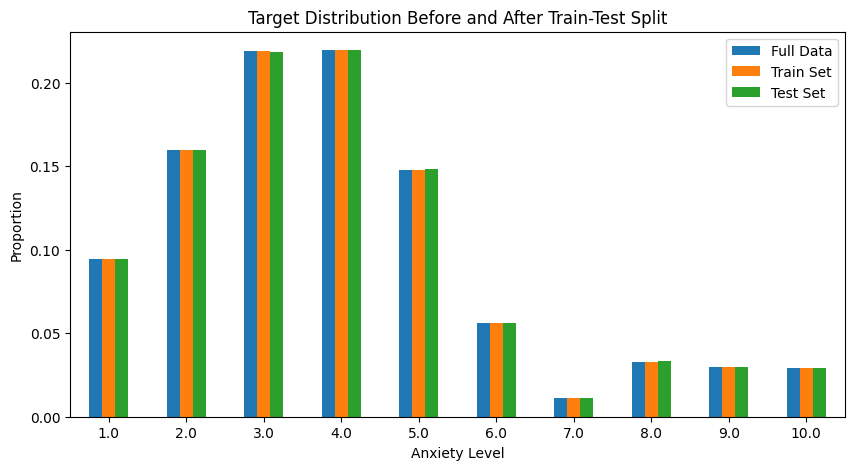

In [25]:
split_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Target Distribution Before and After Train-Test Split")
plt.xlabel("Anxiety Level")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

## 3. Compute Sample Weights

Do biến mục tiêu có phân phối không đồng đều, các mức độ lo âu ít xuất hiện sẽ được gán trọng số cao hơn.

Điều này giúp mô hình không thiên lệch quá nhiều về các nhóm chiếm đa số.

In [26]:
def compute_sample_weights(y):

    value_counts = y.value_counts()

    weights = y.map(lambda x: 1 / value_counts[x])

    weights = weights / weights.mean()

    return weights.values

In [27]:
sample_weights = compute_sample_weights(y_train)

sample_weight_df = pd.DataFrame({
    "Anxiety Level": y_train,
    "Sample Weight": sample_weights
})

sample_weight_summary = sample_weight_df.groupby("Anxiety Level").agg(
    Count=("Anxiety Level", "count"),
    Mean_Weight=("Sample Weight", "mean")
)

sample_weight_summary

,Count,Mean_Weight
Anxiety Level,,
1.0,831,1.058965
2.0,1405,0.626335
3.0,1926,0.456906
4.0,1933,0.455251
5.0,1303,0.675365
6.0,493,1.784990
7.0,98,8.979592
8.0,290,3.034483
9.0,263,3.346008


# Model Selection and Hyperparameter Tuning

Ở bước này, tiến hành so sánh nhiều mô hình Machine Learning khác nhau trên dữ liệu gốc sau khi đã chia train/test.

Mục tiêu của bước này là:

- Xây dựng baseline cho nhiều mô hình.
- Tìm bộ tham số tốt nhất cho từng mô hình bằng `GridSearchCV`.
- Đánh giá các mô hình trên cùng tập test.
- Chọn ra mô hình phù hợp nhất để tiếp tục kiểm tra Feature Engineering.

Các mô hình được sử dụng gồm:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Support Vector Regressor
- XGBoost Regressor

Tiêu chí chính để chọn mô hình là **MAE**, vì MAE cho biết trung bình mô hình dự đoán lệch bao nhiêu mức so với `Anxiety Level` thực tế.

## 1. Run

In [28]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [29]:
model_configs = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Random Forest Regressor": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting Regressor": {
        "model": GradientBoostingRegressor(
            random_state=42
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    },

    "SVR": {
        "model": SVR(),
        "params": {
            "model__C": [1, 10],
            "model__epsilon": [0.1, 0.2],
            "model__kernel": ["rbf"]
        }
    },

    "XGBoost Regressor": {
        "model": XGBRegressor(
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [30]:
def run_model_selection(
    X_train,
    X_test,
    y_train,
    y_test,
    sample_weights,
    model_configs,
    target_col
):

    results = []
    trained_models = {}

    train_data_for_preprocessor = pd.concat(
        [X_train, y_train],
        axis=1
    )

    preprocessor = build_preprocessor(
        train_data_for_preprocessor,
        target_col
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for model_name, config in model_configs.items():
        print("=" * 80)
        print("Training model:", model_name)

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", config["model"])
            ]
        )

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=config["params"],
            scoring="neg_mean_absolute_error",
            cv=cv.split(X_train, y_train.astype(int)),
            n_jobs=-1,
            verbose=1
        )

        try:
            grid_search.fit(
                X_train,
                y_train,
                model__sample_weight=sample_weights
            )

        except TypeError:
            grid_search.fit(
                X_train,
                y_train
            )

        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)

        mae, mse, rmse, r2 = evaluate_regression(
            y_test,
            y_pred
        )

        results.append({
            "Model": model_name,
            "Best Params": grid_search.best_params_,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        })

        trained_models[model_name] = best_model

        print("Best params:", grid_search.best_params_)
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("R2 Score:", r2)

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="MAE").reset_index(drop=True)

    return results_df, trained_models

In [31]:
results_df, trained_models = run_model_selection(
    X_train=X_train_base,
    X_test=X_test_base,
    y_train=y_train,
    y_test=y_test,
    sample_weights=sample_weights,
    model_configs=model_configs,
    target_col=target_col
)

results_df

Training model: Linear Regression
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {}
MAE: 0.9773735645831008
RMSE: 1.223460601729657
R2 Score: 0.6677419271526284
Training model: Random Forest Regressor
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
MAE: 0.8253240808519505
RMSE: 1.027450658869705
R2 Score: 0.7656755995623203
Training model: Gradient Boosting Regressor
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
MAE: 0.8626557001801055
RMSE: 1.0901432982803612
R2 Score: 0.7362073181981345
Training model: SVR
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'model__C': 1, 'model__epsilon': 0.2, 'model__kernel': 'rbf'}
MAE: 0.9284900321026976
RMSE: 1.1737167697974547
R2 Score: 0.6942107709698

,Model,Best Params,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,"{'model__max_depth': 20, 'model__min_samples_l...",0.825324,1.055655,1.027451,0.765676
1,XGBoost Regressor,"{'model__colsample_bytree': 0.8, 'model__learn...",0.856064,1.164008,1.078892,0.741624
2,Gradient Boosting Regressor,"{'model__learning_rate': 0.05, 'model__max_dep...",0.862656,1.188412,1.090143,0.736207
3,SVR,"{'model__C': 1, 'model__epsilon': 0.2, 'model_...",0.928490,1.377611,1.173717,0.694211
4,Linear Regression,{},0.977374,1.496856,1.223461,0.667742


## 2. Visualize

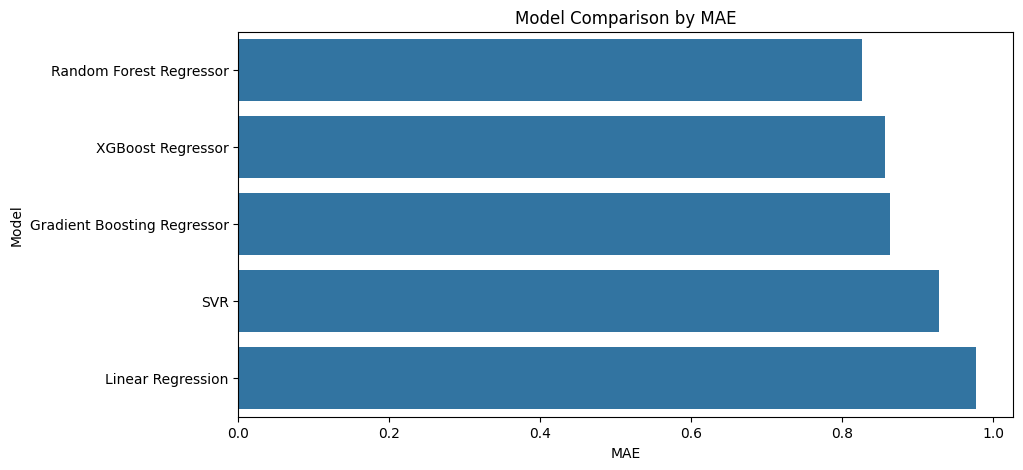

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)
plt.title("Model Comparison by MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

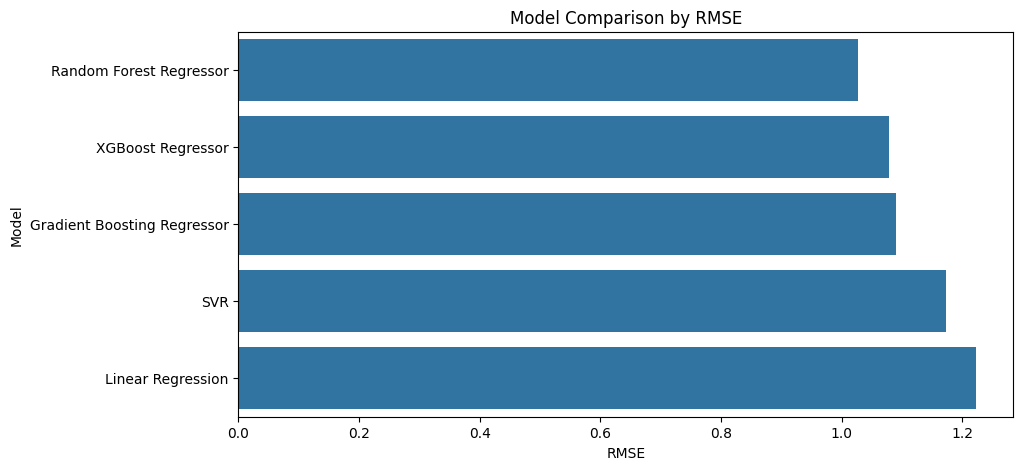

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

# Best Model Selection

Sau khi so sánh các mô hình trên dữ liệu gốc, mô hình có MAE thấp nhất được chọn làm mô hình tốt nhất ban đầu.

Mô hình này sẽ được giữ cố định trong bước tiếp theo để đánh giá tác động của các chiến lược Feature Engineering.

Việc giữ cố định mô hình giúp đảm bảo rằng mọi cải thiện quan sát được đến từ engineered features thay vì do thay đổi thuật toán.

In [34]:
best_model_name = results_df.iloc[0]["Model"]
best_model_params = results_df.iloc[0]["Best Params"]

best_model_summary = pd.DataFrame({
    "Best Model": [best_model_name],
    "Best Parameters": [best_model_params]
})

best_model_summary

,Best Model,Best Parameters
0,Random Forest Regressor,"{'model__max_depth': 20, 'model__min_samples_l..."


# Feature Engineering Comparison

Sau khi chọn được mô hình tốt nhất từ bước Model Selection, bước tiếp theo là đánh giá tác động của các chiến lược Feature Engineering.

Mục tiêu của bước này là kiểm tra xem việc tạo thêm các đặc trưng mới có thực sự giúp cải thiện hiệu quả dự đoán hay không.

Để đảm bảo so sánh công bằng:

- cùng một mô hình sẽ được giữ cố định
- cùng bộ hyperparameters tốt nhất sẽ được sử dụng
- cùng train/test split sẽ được giữ nguyên

Như vậy, mọi khác biệt về hiệu suất sẽ chủ yếu đến từ engineered features thay vì do thay đổi mô hình.

## 1. Run

In [35]:
def run_feature_engineering_comparison(
    X_train_base,
    X_test_base,
    y_train,
    y_test,
    sample_weights,
    best_model_name,
    best_model_params,
    model_configs,
    target_col
):

    results = {}
    trained_models = {}

    base_model = model_configs[best_model_name]["model"]

    for case_name in fe_cases:
        print("=" * 80)
        print("Feature Engineering Case:", case_name)

        # Apply FE separately to avoid leakage
        X_train_fe = add_feature_engineering(
            X_train_base.copy(),
            case_name
        )

        X_test_fe = add_feature_engineering(
            X_test_base.copy(),
            case_name
        )

        # Rebuild preprocessor because feature columns changed
        train_data_for_preprocessor = pd.concat(
            [X_train_fe, y_train],
            axis=1
        )

        preprocessor = build_preprocessor(
            train_data_for_preprocessor,
            target_col
        )

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", base_model)
            ]
        )

        pipeline.set_params(**best_model_params)

        try:
            pipeline.fit(
                X_train_fe,
                y_train,
                model__sample_weight=sample_weights
            )

        except TypeError:
            pipeline.fit(
                X_train_fe,
                y_train
            )

        y_pred = pipeline.predict(X_test_fe)

        mae, mse, rmse, r2 = evaluate_regression(
            y_test,
            y_pred
        )

        results[case_name] = {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        }

        trained_models[case_name] = pipeline

        print("MAE:", mae)
        print("RMSE:", rmse)
        print("R2:", r2)

    results_df = pd.DataFrame(results).T.reset_index()
    results_df = results_df.rename(
        columns={"index": "Feature Engineering Case"}
    )

    results_df = results_df.sort_values(
        by="MAE"
    ).reset_index(drop=True)

    return results_df, trained_models

In [36]:
fe_results_df, fe_trained_models = run_feature_engineering_comparison(
    X_train_base=X_train_base,
    X_test_base=X_test_base,
    y_train=y_train,
    y_test=y_test,
    sample_weights=sample_weights,
    best_model_name=best_model_name,
    best_model_params=best_model_params,
    model_configs=model_configs,
    target_col=target_col
)

fe_results_df

Feature Engineering Case: Original
MAE: 0.8253240808519505
RMSE: 1.027450658869705
R2: 0.7656755995623203
Feature Engineering Case: Lifestyle_Features
MAE: 0.8256921549728955
RMSE: 1.025488312807442
R2: 0.7665698253746525
Feature Engineering Case: Stress_Features
MAE: 0.8146356171705722
RMSE: 1.0202749599885594
R2: 0.7689372058379045
Feature Engineering Case: Physiological_Features
MAE: 0.8269666083767553
RMSE: 1.0306754337223638
R2: 0.7642023818164341
Feature Engineering Case: Interaction_Features
MAE: 0.8245722693091257
RMSE: 1.0287381019086954
R2: 0.7650879930925606
Feature Engineering Case: Combined_Features
MAE: 0.8162953983526913
RMSE: 1.0219678977628242
R2: 0.7681697666960188


,Feature Engineering Case,MAE,MSE,RMSE,R2 Score
0,Stress_Features,0.814636,1.040961,1.020275,0.768937
1,Combined_Features,0.816295,1.044418,1.021968,0.768170
2,Interaction_Features,0.824572,1.058302,1.028738,0.765088
3,Original,0.825324,1.055655,1.027451,0.765676
4,Lifestyle_Features,0.825692,1.051626,1.025488,0.766570
5,Physiological_Features,0.826967,1.062292,1.030675,0.764202


## 2. Visualize

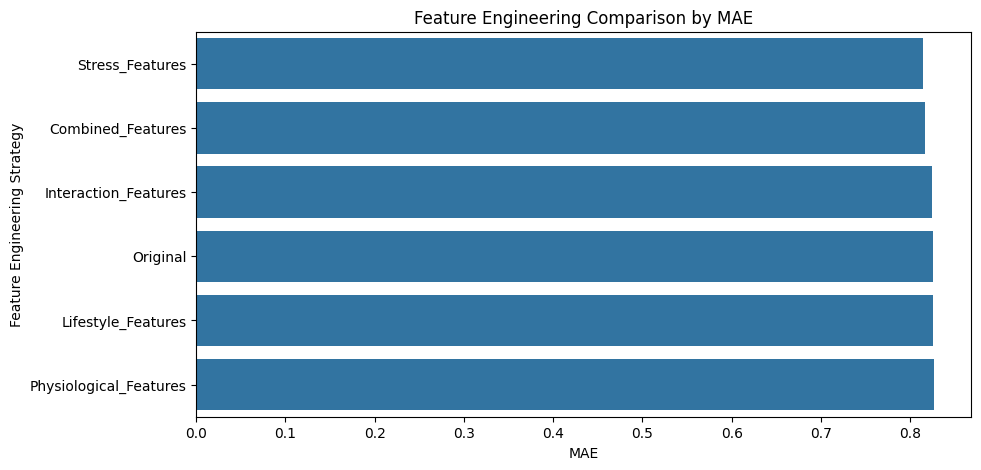

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fe_results_df,
    x="MAE",
    y="Feature Engineering Case"
)

plt.title("Feature Engineering Comparison by MAE")
plt.xlabel("MAE")
plt.ylabel("Feature Engineering Strategy")
plt.show()

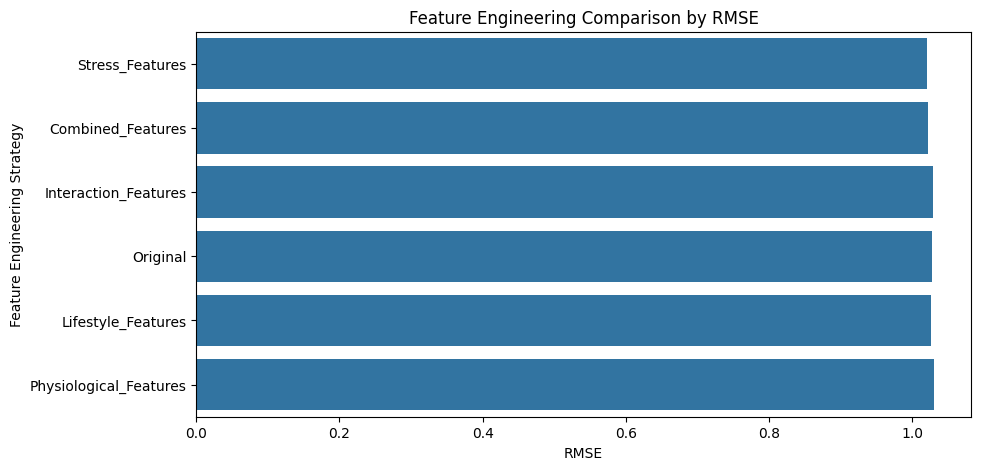

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fe_results_df,
    x="RMSE",
    y="Feature Engineering Case"
)

plt.title("Feature Engineering Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Feature Engineering Strategy")
plt.show()

## 3. Select Best FE

In [39]:
best_fe_case = fe_results_df.iloc[0]["Feature Engineering Case"]

print("Best Feature Engineering Case:", best_fe_case)

Best Feature Engineering Case: Stress_Features


# Final Model Training

In [40]:
final_config = pd.DataFrame({
    "Component": [
        "Best Model",
        "Best Hyperparameters",
        "Best Feature Engineering"
    ],
    "Selected Option": [
        best_model_name,
        str(best_model_params),
        best_fe_case
    ]
})

final_config

,Component,Selected Option
0,Best Model,Random Forest Regressor
1,Best Hyperparameters,"{'model__max_depth': 20, 'model__min_samples_l..."
2,Best Feature Engineering,Stress_Features


In [41]:
X_train_final = add_feature_engineering(
    X_train_base.copy(),
    best_fe_case
)

X_test_final = add_feature_engineering(
    X_test_base.copy(),
    best_fe_case
)

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (8800, 21)
Final test shape: (2200, 21)


In [42]:
train_data_for_preprocessor = pd.concat(
    [X_train_final, y_train],
    axis=1
)

final_preprocessor = build_preprocessor(
    train_data_for_preprocessor,
    target_col
)

final_preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


In [43]:
final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        (
            "model",
            model_configs[best_model_name]["model"]
        )
    ]
)

final_model.set_params(**best_model_params)

final_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
final_model.fit(
  X_train_final,
  y_train,
  model__sample_weight=sample_weights
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Final Evaluation

In [45]:
y_pred_final = final_model.predict(X_test_final)

print("Number of predictions:", len(y_pred_final))

Number of predictions: 2200


In [46]:
final_mae, final_mse, final_rmse, final_r2 = evaluate_regression(
    y_test,
    y_pred_final
)

In [47]:
final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Value": [
        final_mae,
        final_mse,
        final_rmse,
        final_r2
    ]
})

final_results

,Metric,Value
0,MAE,0.814636
1,MSE,1.040961
2,RMSE,1.020275
3,R2 Score,0.768937


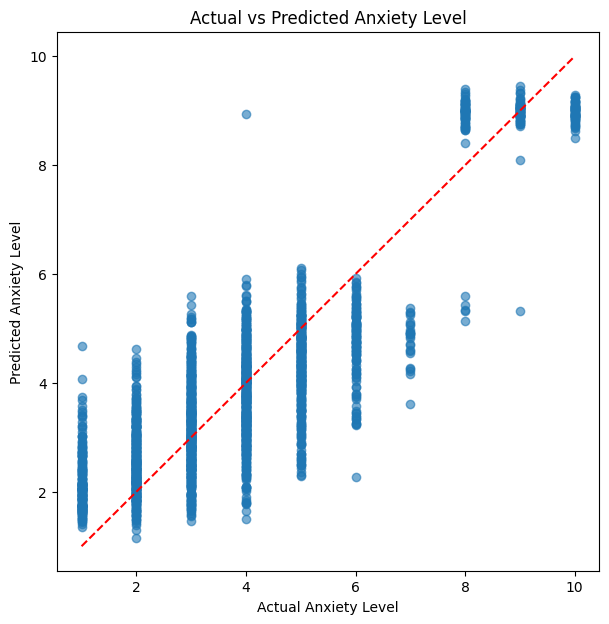

In [48]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_final,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Anxiety Level")
plt.ylabel("Predicted Anxiety Level")
plt.title("Actual vs Predicted Anxiety Level")

plt.show()

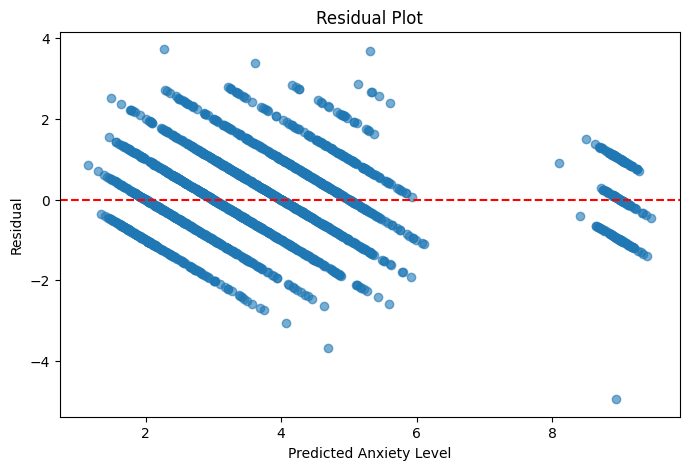

In [49]:
residuals = y_test - y_pred_final

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_final,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--",
    color="red"
)

plt.xlabel("Predicted Anxiety Level")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Kết quả đánh giá cho thấy mô hình cuối cùng đạt hiệu suất khá tốt:

- MAE = 0.814
- RMSE = 1.020
- R² = 0.769

Điều này cho thấy trung bình mô hình dự đoán lệch khoảng 0.8 mức anxiety so với giá trị thực tế, đồng thời giải thích được khoảng 76.9% biến thiên của target.

So với baseline model trước Feature Engineering, hiệu suất đã được cải thiện nhẹ, cho thấy các engineered features mang lại lợi ích nhất định.

Biểu đồ Actual vs Predicted cho thấy mô hình học được xu hướng tổng quát giữa các mức anxiety, tuy nhiên vẫn tồn tại hiện tượng dự đoán co về giá trị trung bình (regression to the mean), đặc biệt ở các mức anxiety rất cao.

Residual plot cho thấy sai số phân bố tương đối hợp lý, tuy nhiên độ phân tán ở một số vùng vẫn còn khá lớn, đặc biệt ở các mức anxiety thấp đến trung bình.

Nhìn chung, mô hình có khả năng tổng quát hóa tốt, nhưng vẫn còn dư địa cải thiện trong việc dự đoán các mức anxiety cực trị.

# Error Analysis

Các chỉ số tổng thể như MAE, RMSE và R² cho biết hiệu suất chung của mô hình, nhưng chưa cho biết mô hình hoạt động tốt hoặc kém ở những mức độ anxiety nào.

Do biến mục tiêu `Anxiety Level` là biến rời rạc từ 1 đến 10, việc phân tích lỗi theo từng mức độ anxiety giúp:

- xác định nhóm mà mô hình dự đoán tốt
- phát hiện nhóm mà mô hình dự đoán kém
- kiểm tra tác động của mất cân bằng dữ liệu
- hiểu rõ hơn giới hạn của mô hình

## 1. Group Errors

In [50]:
error_analysis_df = pd.DataFrame({
    "Actual Anxiety Level": y_test.values,
    "Predicted Anxiety Level": y_pred_final,
})

error_analysis_df["Absolute Error"] = np.abs(
    error_analysis_df["Actual Anxiety Level"]
    - error_analysis_df["Predicted Anxiety Level"]
)

error_analysis_df.head()

,Actual Anxiety Level,Predicted Anxiety Level,Absolute Error
0,2.0,3.038642,1.038642
1,5.0,3.187506,1.812494
2,4.0,3.441573,0.558427
3,8.0,8.984034,0.984034
4,5.0,5.400282,0.400282


In [51]:
grouped_error = error_analysis_df.groupby(
    "Actual Anxiety Level"
).agg(
    Sample_Count=("Actual Anxiety Level", "count"),
    Mean_Absolute_Error=("Absolute Error", "mean"),
    Std_Absolute_Error=("Absolute Error", "std")
).reset_index()

grouped_error

,Actual Anxiety Level,Sample_Count,Mean_Absolute_Error,Std_Absolute_Error
0,1.0,208,1.185587,0.546384
1,2.0,351,0.677282,0.553326
2,3.0,481,0.676894,0.508066
3,4.0,483,0.723118,0.545305
4,5.0,326,0.806131,0.654911
5,6.0,123,1.281390,0.701751
6,7.0,25,2.226809,0.420346
7,8.0,73,1.082072,0.461924
8,9.0,66,0.183339,0.458199
9,10.0,64,1.028864,0.162463


## 2. MAE by Level

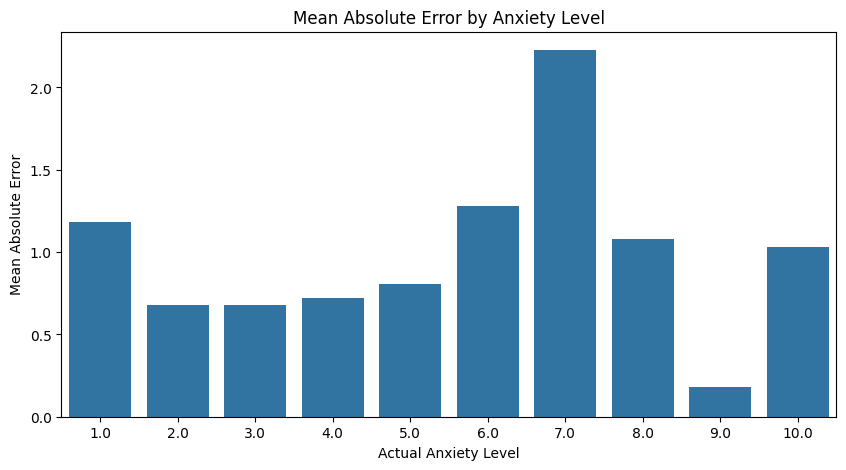

In [52]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=grouped_error,
    x="Actual Anxiety Level",
    y="Mean_Absolute_Error"
)

plt.title("Mean Absolute Error by Anxiety Level")
plt.xlabel("Actual Anxiety Level")
plt.ylabel("Mean Absolute Error")

plt.show()

## 3. Sample Count Plot

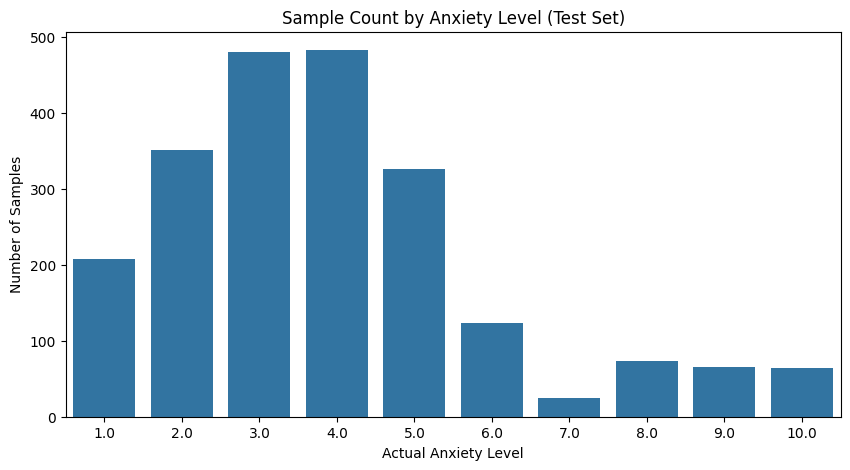

In [53]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=grouped_error,
    x="Actual Anxiety Level",
    y="Sample_Count"
)

plt.title("Sample Count by Anxiety Level (Test Set)")
plt.xlabel("Actual Anxiety Level")
plt.ylabel("Number of Samples")

plt.show()

## 4. Error Histogram

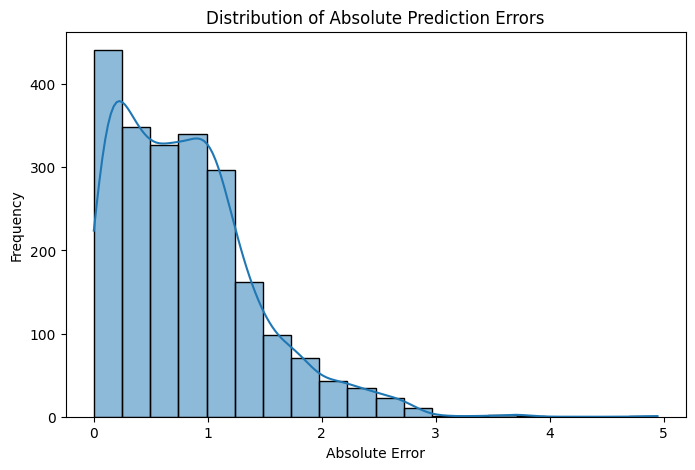

In [54]:
plt.figure(figsize=(8, 5))

sns.histplot(
    error_analysis_df["Absolute Error"],
    bins=20,
    kde=True
)

plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

## 5. Worst Cases

In [55]:
worst_cases = error_analysis_df.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

worst_cases

,Actual Anxiety Level,Predicted Anxiety Level,Absolute Error
1060,4.0,8.945406,4.945406
1380,6.0,2.274433,3.725567
982,1.0,4.684881,3.684881
1690,9.0,5.317830,3.682170
577,7.0,3.607203,3.392797
2048,1.0,4.068528,3.068528
1576,8.0,5.131462,2.868538
1354,7.0,4.164221,2.835779
1915,6.0,3.217893,2.782107
1119,7.0,4.219577,2.780423


## Analysis

Phân tích lỗi theo từng mức `Anxiety Level` cho thấy mô hình không hoạt động đồng đều trên toàn bộ các nhóm target.

### 1. Performance tốt nhất ở các mức anxiety trung bình

Các mức anxiety phổ biến như:

- Level 2 → MAE = 0.679
- Level 3 → MAE = 0.675
- Level 4 → MAE = 0.722
- Level 5 → MAE = 0.804

đều có sai số tương đối thấp.

Đây cũng là các nhóm có số lượng mẫu lớn nhất trong tập test:

- Level 3 → 481 samples
- Level 4 → 483 samples
- Level 5 → 326 samples

Điều này cho thấy mô hình học tốt hơn ở các mức có nhiều dữ liệu huấn luyện.

---

### 2. Performance giảm rõ rệt ở các mức ít dữ liệu

Các mức anxiety có ít sample hơn thường có sai số cao hơn:

- Level 6 → MAE = 1.283
- Level 7 → MAE = 2.226
- Level 10 → MAE = 1.034

Đặc biệt:

- Level 7 chỉ có 25 samples nhưng MAE cao nhất.

Điều này cho thấy ảnh hưởng rõ ràng của target imbalance.

Mặc dù sample weighting đã được áp dụng, số lượng mẫu quá ít vẫn khiến mô hình khó học chính xác ở các mức này.

---

### 3. Level 9 có kết quả bất thường

Level 9:

- chỉ có 66 samples
- nhưng MAE chỉ 0.185

Đây là mức sai số thấp bất thường so với các nhóm ít dữ liệu khác.

Điều này cho thấy các sample ở level 9 có thể có pattern rõ ràng hơn, giúp mô hình nhận diện dễ hơn.

Ngoài ra, Random Forest có xu hướng dự đoán co cụm quanh các vùng đã học tốt, nên nếu nhiều sample level 9 có đặc trưng tương đối giống nhau thì model có thể dự đoán ổn định hơn.

---

### 4. Error distribution cho thấy đa số dự đoán khá chính xác

Histogram sai số tuyệt đối cho thấy:

- phần lớn prediction errors nằm dưới 1.5
- phần lớn mẫu có sai số dưới 1 mức anxiety

Điều này phù hợp với kết quả MAE tổng thể:

$$
MAE = 0.814
$$

Tuy nhiên, vẫn tồn tại một số trường hợp outlier với sai số lớn:

- maximum error gần 5 mức anxiety

Điều này cho thấy dù mô hình hoạt động tốt trung bình, vẫn có một số tình huống khó dự đoán.

---

### 5. Worst prediction cases

Một số trường hợp sai số lớn nhất:

- Actual 4 → Predicted 8.95
- Actual 6 → Predicted 2.29
- Actual 9 → Predicted 5.30
- Actual 1 → Predicted 4.67
- Actual 7 → Predicted 3.66

Các trường hợp này cho thấy mô hình đôi khi:

- đánh giá quá cao các mức anxiety thấp
- đánh giá quá thấp các mức anxiety cao

Đây là dấu hiệu của hiện tượng: **regression toward the mean** tức là mô hình có xu hướng kéo prediction về vùng trung bình thay vì dự đoán chính xác các giá trị cực trị.

---

### 6. Overall conclusion

Nhìn chung:

- mô hình hoạt động tốt ở các mức anxiety phổ biến
- hiệu suất giảm ở các nhóm ít dữ liệu
- tồn tại một số lỗi lớn ở các trường hợp cực trị
- sample imbalance vẫn là một thách thức đáng kể

Tuy nhiên, xét trên toàn bộ tập test, mô hình vẫn cho khả năng tổng quát hóa tốt với sai số trung bình thấp và hiệu suất ổn định trên phần lớn dữ liệu.

# Save Models


## 1. Save all trained model candidates


In [56]:
from pathlib import Path
import json
import re
import joblib
import numpy as np

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


MODEL_ARTIFACT_NAMES = {
    "Linear Regression": "linear_regression",
    "Random Forest Regressor": "random_forest",
    "Gradient Boosting Regressor": "gradient_boosting",
    "SVR": "svr",
    "XGBoost Regressor": "xgboost"
}


def to_slug(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


def model_artifact_name(model_name):
    return MODEL_ARTIFACT_NAMES.get(model_name, to_slug(model_name))


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


model_registry = []

for _, row in results_df.iterrows():
    model_name = row["Model"]
    model_slug = model_artifact_name(model_name)
    filename = f"{model_slug}.pkl"
    model_path = SAVE_DIR / filename

    joblib.dump(trained_models[model_name], model_path)

    model_registry.append({
        "name": model_slug,
        "display_name": model_name,
        "filename": filename,
        "metrics": {
            "mae": float(row["MAE"]),
            "mse": float(row["MSE"]),
            "rmse": float(row["RMSE"]),
            "r2": float(row["R2 Score"])
        },
        "best_params": json_safe(row["Best Params"]),
        "is_best": model_name == best_model_name
    })

print("Saved model candidates:")
for item in model_registry:
    marker = " (best base model)" if item["is_best"] else ""
    print(f"- {item['display_name']} -> {SAVE_DIR / item['filename']}{marker}")



Saved model candidates:
- Random Forest Regressor -> saved_models\random_forest.pkl (best base model)
- XGBoost Regressor -> saved_models\xgboost.pkl
- Gradient Boosting Regressor -> saved_models\gradient_boosting.pkl
- SVR -> saved_models\svr.pkl
- Linear Regression -> saved_models\linear_regression.pkl


## 2. Save best base model and feature-engineering variants


In [57]:
best_base_model_filename = "best_model.pkl"
best_base_model_path = SAVE_DIR / best_base_model_filename
joblib.dump(trained_models[best_model_name], best_base_model_path)

feature_engineering_registry = []

for _, row in fe_results_df.iterrows():
    fe_case = row["Feature Engineering Case"]
    fe_slug = to_slug(fe_case)
    filename = f"best_model_{fe_slug}.pkl"
    model_path = SAVE_DIR / filename

    joblib.dump(fe_trained_models[fe_case], model_path)

    feature_engineering_registry.append({
        "name": fe_slug,
        "display_name": fe_case,
        "filename": filename,
        "metrics": {
            "mae": float(row["MAE"]),
            "mse": float(row["MSE"]),
            "rmse": float(row["RMSE"]),
            "r2": float(row["R2 Score"])
        },
        "is_best": fe_case == best_fe_case
    })

print("Best base model saved to:", best_base_model_path)
print("Saved feature-engineering variants:")
for item in feature_engineering_registry:
    marker = " (best FE model)" if item["is_best"] else ""
    print(f"- {item['display_name']} -> {SAVE_DIR / item['filename']}{marker}")


Best base model saved to: saved_models\best_model.pkl
Saved feature-engineering variants:
- Stress_Features -> saved_models\best_model_stress_features.pkl (best FE model)
- Combined_Features -> saved_models\best_model_combined_features.pkl
- Interaction_Features -> saved_models\best_model_interaction_features.pkl
- Original -> saved_models\best_model_original.pkl
- Lifestyle_Features -> saved_models\best_model_lifestyle_features.pkl
- Physiological_Features -> saved_models\best_model_physiological_features.pkl


## 3. Save final production model and metadata


In [58]:
FINAL_MODEL_FILENAME = "final_anxiety_prediction_model.pkl"
FINAL_MODEL_PATH = SAVE_DIR / FINAL_MODEL_FILENAME
joblib.dump(final_model, FINAL_MODEL_PATH)

BEST_FINAL_MODEL_FILENAME = "best_final_model.pkl"
BEST_FINAL_MODEL_PATH = SAVE_DIR / BEST_FINAL_MODEL_FILENAME
joblib.dump(final_model, BEST_FINAL_MODEL_PATH)

experiment_metadata = {
    "best_model_name": best_model_name,
    "best_model_slug": model_artifact_name(best_model_name),
    "best_model_params": json_safe(best_model_params),
    "best_feature_engineering": best_fe_case,
    "target_column": target_col,
    "input_columns": list(X.columns),
    "final_input_columns": list(X_train_final.columns),
    "artifacts": {
        "save_dir": str(SAVE_DIR),
        "best_base_model": best_base_model_filename,
        "final_model": FINAL_MODEL_FILENAME,
        "best_final_model": BEST_FINAL_MODEL_FILENAME,
        "model_registry": "model_registry.json",
        "feature_engineering_registry": "feature_engineering_registry.json"
    },
    "final_metrics": {
        "MAE": float(final_mae),
        "MSE": float(final_mse),
        "RMSE": float(final_rmse),
        "R2 Score": float(final_r2)
    }
}

model_registry_payload = {
    "models": model_registry,
    "best_model": model_artifact_name(best_model_name),
    "best_model_file": best_base_model_filename,
    "final_model": FINAL_MODEL_FILENAME
}

feature_engineering_registry_payload = {
    "models": feature_engineering_registry,
    "best_feature_engineering": to_slug(best_fe_case),
    "best_feature_engineering_file": f"best_model_{to_slug(best_fe_case)}.pkl"
}

with open(SAVE_DIR / "model_registry.json", "w", encoding="utf-8") as f:
    json.dump(model_registry_payload, f, indent=2, ensure_ascii=False)

with open(SAVE_DIR / "feature_engineering_registry.json", "w", encoding="utf-8") as f:
    json.dump(feature_engineering_registry_payload, f, indent=2, ensure_ascii=False)

with open(SAVE_DIR / "experiment_metadata.json", "w", encoding="utf-8") as f:
    json.dump(experiment_metadata, f, indent=2, ensure_ascii=False)

joblib.dump(experiment_metadata, SAVE_DIR / "experiment_metadata.pkl")

print("Final model saved to:", FINAL_MODEL_PATH)
print("Best final model saved to:", BEST_FINAL_MODEL_PATH)
print("Metadata and registries saved to:", SAVE_DIR)



Final model saved to: saved_models\final_anxiety_prediction_model.pkl
Best final model saved to: saved_models\best_final_model.pkl
Metadata and registries saved to: saved_models


## 4. Check saved final model


In [59]:
loaded_model = joblib.load(FINAL_MODEL_PATH)

print(type(loaded_model))

sample_prediction = loaded_model.predict(
    X_test_final.head(5)
)

print("Sample predictions:")
print(sample_prediction)


<class 'sklearn.pipeline.Pipeline'>
Sample predictions:
[3.0386421  3.1875059  3.44157285 8.98403434 5.40028223]
